<a href="https://colab.research.google.com/github/amanak28/AI-LAB/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: BFS and DFS Traversal of a Graph:

Problem Statement:

A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:

1. Stores the graph using an adjacency list (a Python dictionary).

2. Performs a BFS traversal starting from node A.

3. Performs a DFS traversal starting from node A.

4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.\

---



In [4]:
!pip install networkx matplotlib

BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


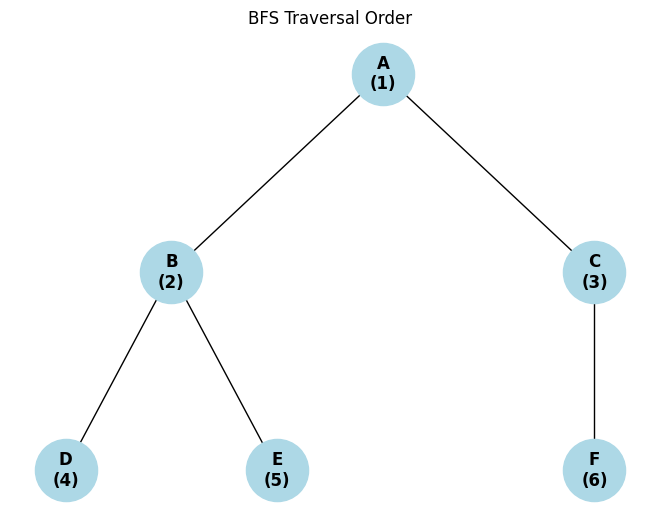

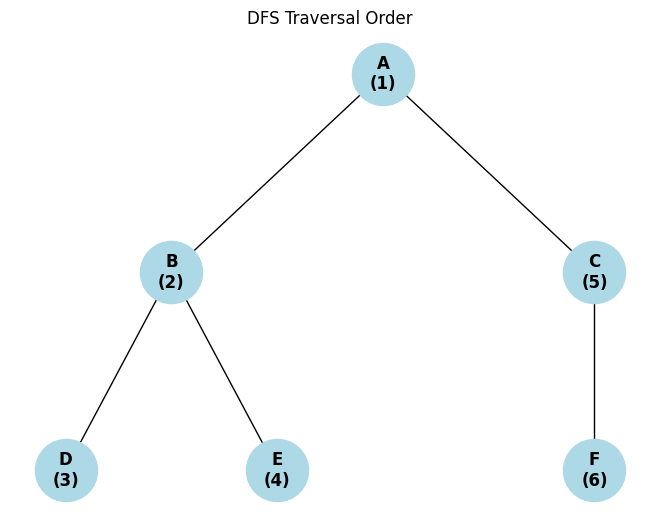

In [5]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

# Graph represented as an adjacency list
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    order = []
    visited.add(start)

    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)
    return order

def dfs(graph, start):
    visited = set()
    order = []

    def dfs_recursive(node):
        visited.add(node)
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                dfs_recursive(neighbour)

    dfs_recursive(start)
    return order

bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))

def draw_tree(graph, order, title):
    G = nx.DiGraph()
    for node in graph:
        for neighbour in graph[node]:
            G.add_edge(node, neighbour)

    pos = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    labels = {
        node: f"{node}\n({order.index(node) + 1})"
        for node in order
    }

    plt.figure()
    nx.draw(
        G, pos, with_labels=True, labels=labels,
        node_size=2000, node_color="lightblue",
        font_size=12, font_weight="bold", arrows=False
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

draw_tree(graph, bfs_order, "BFS Traversal Order")
draw_tree(graph, dfs_order, "DFS Traversal Order")

Problem 2: The Water Jug Problem (Solved using BFS)

Problem Statement:

You are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings on it. Using only the following operations — (i) fill a jug completely, (ii) empty a jug completely, (iii) pour water from one jug into the other until either the first jug is empty or the second jug is full — determine the minimum sequence of steps needed to measure out exactly 2 litres of water in any one jug.

In [6]:
from collections import deque

def water_jug_bfs():
    capacity_a = 4
    capacity_b = 3
    target = 2

    start = (0, 0)
    queue = deque([start])
    visited = {start}
    parent = {start: (None, "Start")}

    goal = None
    while queue:
        a, b = queue.popleft()
        if a == target or b == target:
            goal = (a, b)
            break

        next_states = [
            ((capacity_a, b), "Fill Jug A"),
            ((a, capacity_b), "Fill Jug B"),
            ((0, b), "Empty Jug A"),
            ((a, 0), "Empty Jug B")
        ]

        # Pour A -> B
        amount = min(a, capacity_b - b)
        next_states.append(((a - amount, b + amount), "Pour A -> B"))

        # Pour B -> A
        amount = min(b, capacity_a - a)
        next_states.append(((a + amount, b - amount), "Pour B -> A"))

        for state, operation in next_states:
            if state not in visited:
                visited.add(state)
                queue.append(state)
                parent[state] = ((a, b), operation)

    path = []
    current = goal
    while current is not None:
        previous, operation = parent[current]
        path.append((current, operation))
        current = previous

    path.reverse()

    for i, (state, operation) in enumerate(path):
        if i == 0:
            print(f"{state} {operation}")
        else:
            print(f"Step {i}: {operation}\nState {state}")

water_jug_bfs()

(0, 0) Start
Step 1: Fill Jug B
State (0, 3)
Step 2: Pour B -> A
State (3, 0)
Step 3: Fill Jug B
State (3, 3)
Step 4: Pour B -> A
State (4, 2)


Problem 3: Checking Routes Between Cities Using DFS

Problem Statement:

A small road network connects several cities. Write a Python program using DFS that:

1. Checks whether a route exists between two given cities.

2. Finds all separate groups of cities that are connected to each other but not to any

other group (these are called connected components).

In [7]:
roads = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'C': ['A'],
    'D': ['B'],
    'E': ['F'],
    'F': ['E']
}

def route_exists(graph, start, destination):
    visited = set()

    def dfs(city):
        if city == destination:
            return True
        visited.add(city)
        for neighbour in graph[city]:
            if neighbour not in visited:
                if dfs(neighbour):
                    return True
        return False

    return dfs(start)

def connected_components(graph):
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            component = []

            def dfs(node):
                visited.add(node)
                component.append(node)
                for neighbour in graph[node]:
                    if neighbour not in visited:
                        dfs(neighbour)

            dfs(city)
            components.append(component)

    return components

print("Route Checking:")
if route_exists(roads, 'A', 'D'):
    print("Route exists from A to D")
else:
    print("No route exists from A to D")

if route_exists(roads, 'A', 'F'):
    print("Route exists from A to F")
else:
    print("No route exists from A to F")

components = connected_components(roads)
print("\nConnected Components:")
for i, component in enumerate(components, start=1):
    print(f"Component {i}: {component}")

Route Checking:
Route exists from A to D
No route exists from A to F

Connected Components:
Component 1: ['A', 'B', 'D', 'C']
Component 2: ['E', 'F']
